# NLP from Scratch: A Classroom Demo + Study Notebook

**Audience:** First-time NLP learners  
**Goal:** Move from raw text to Bag of Words, TF-IDF, static embeddings, and contextual embeddings.

---

## How to use this notebook

- In class: run one section at a time and discuss each visualization.
- After class: read markdown explanations and revisit outputs at your own pace.
- This notebook is intentionally **teaching-first**, not only implementation-first.

## Setup and Dependencies

This notebook uses common Python NLP/data-science libraries plus two modern NLP packages.

### If needed, install packages
Uncomment and run:
```python
# !pip install scikit-learn pandas numpy matplotlib seaborn nltk wordcloud datasets sentence-transformers transformers torch
```

### Why these libraries?
- `scikit-learn`: classic NLP features (Bag of Words, TF-IDF) + simple models.
- `nltk`: tokenization, stopwords, stemming, lemmatization.
- `datasets`: easy access to IMDB reviews dataset.
- `sentence-transformers`: lightweight semantic embeddings.
- `transformers`: contextual token embeddings from BERT-family models.

In [1]:
# Core Python and data tools
import re
import string
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Classical NLP and ML tools
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# NLTK preprocessing utilities
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Embedding packages
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

# Plot style for consistent classroom visuals
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)

# Download NLTK resources (safe to run multiple times)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print('Libraries imported successfully.')

Libraries imported successfully.


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Brent\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Brent\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Brent\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Brent\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


---
# Section 1: What is NLP?

Natural Language Processing (NLP) is the field of teaching computers to process and reason about human language.

## Common NLP tasks
- Sentiment analysis (positive vs negative opinions)
- Topic classification (e.g., sports vs politics)
- Search and information retrieval
- Question answering
- Translation
- Summarization

Below, we load a classroom-friendly subset of the **20 Newsgroups** dataset.

In [2]:
# We use 4 categories so students can clearly see topic differences.
categories = ['sci.space', 'comp.graphics', 'rec.sport.baseball', 'talk.politics.misc']

newsgroups = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes')
)

# Convert into a DataFrame for easier exploration and plotting.
df = pd.DataFrame({
    'text': newsgroups.data,
    'target': newsgroups.target
})
df['label'] = df['target'].map(lambda x: newsgroups.target_names[x])

# Basic cleanup: drop empty or near-empty documents that can be noisy in demos.
df['text'] = df['text'].fillna('').str.strip()
df = df[df['text'].str.len() > 20].reset_index(drop=True)

print(f"Number of documents: {len(df)}")
print('Classes:', sorted(df['label'].unique()))
df.head(3)

Number of documents: 2159
Classes: ['comp.graphics', 'rec.sport.baseball', 'sci.space', 'talk.politics.misc']


,text,target,label
0,I thought that was Sandy Koufax.,1,rec.sport.baseball
1,"And the religious right worships engines, smok...",3,talk.politics.misc
2,How can a witness tell that someone in a burni...,3,talk.politics.misc


### Step Review (Dataset Selection and Fetching)
**1) Brand-new student view:** We are choosing four topics so the model has clearly different kinds of text to learn from. Think of this like making four labeled bins before sorting messages.

**2) ML professor view:** Good pedagogical class choice because semantic separation is high and vocabulary overlap is moderate. To reduce confusion, explicitly tell students that the dataset is *already labeled* (supervised learning setup), and mention that classes are intentionally not exhaustive.

**3) Student re-check after professor edits:** The explanation works better when we clearly state: *we are not discovering topics; we are learning from known labels*.


### Inspecting raw text (important for beginners)

Before doing any preprocessing, always look at raw examples.
Students should notice:
- inconsistent punctuation/casing,
- irrelevant symbols,
- variable document length,
- realistic messiness of human language data.

In [4]:
# Show one sample from each class to make topic differences concrete.
# Show one sample from each class to make topic differences concrete.
for label in sorted(df['label'].unique()):
    sample = df[df['label'] == label]['text'].iloc[0][:600]
    print('=' * 95)
    print(f'Class: {label}')
    print('-' * 95)
    print(sample)
    print()

Class: comp.graphics
-----------------------------------------------------------------------------------------------
While I don't mean to damn Henrik's attempt to be helpful here,
he's using a common misconception that should be corrected.

    Mach banding will occur for any image.  It is not the color
quantization you see when you don't have enough bits.  It is the
human eye's response to transitions or edges between intensities.
The result is that colors near the transistion look brighter on
the brighter side and darker on the darker side.

--Andre

Class: rec.sport.baseball
-----------------------------------------------------------------------------------------------
I thought that was Sandy Koufax.

Class: sci.space
-----------------------------------------------------------------------------------------------
Yes, long before Star Trek.  Before Einstein, in fact.

Vulcan as a planet inside Mercury was hypothesized to explain a perturbation
of Mercury's orbit that could not be e

C:\Users\Brent\AppData\Local\Temp\ipykernel_32028\2799810710.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='Set2')


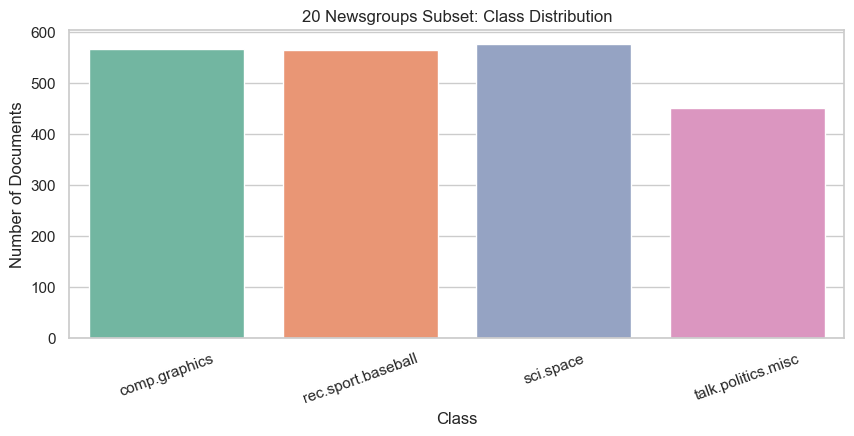

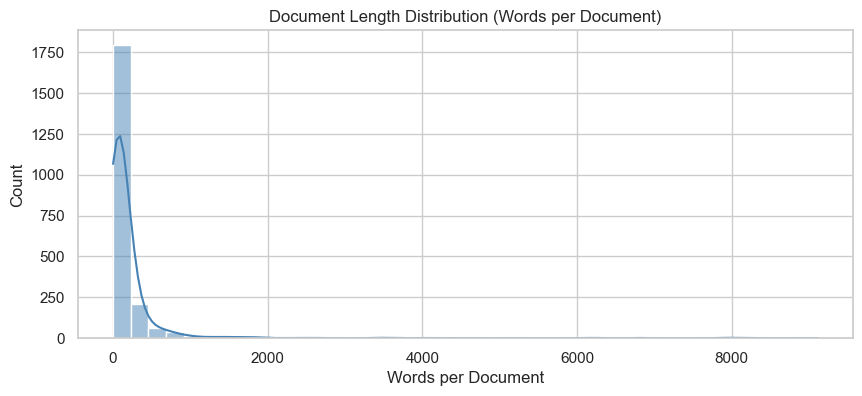

In [5]:
# Visual 1: class distribution
class_counts = df['label'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='Set2')
plt.title('20 Newsgroups Subset: Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Documents')
plt.xticks(rotation=20)
plt.show()

# Visual 2: document length distribution (in words)
df['doc_length_words'] = df['text'].str.split().str.len()

plt.figure(figsize=(10, 4))
sns.histplot(df['doc_length_words'], bins=40, kde=True, color='steelblue')
plt.title('Document Length Distribution (Words per Document)')
plt.xlabel('Words per Document')
plt.ylabel('Count')
plt.show()

### Step Review (Class Distribution Visualization)
**1) Brand-new student view:** This bar chart answers: “Do we have roughly balanced classes?” If one bar is much taller, the model could bias toward that class.

**2) ML professor view:** Add a sentence defining class imbalance and why baseline accuracy can become misleading. Also call out that this is a *label prior* view only, not feature quality.

**3) Student re-check after professor edits:** I now understand this chart is about fairness of training examples, not about how informative the words are.


---
# Section 2: Text Preprocessing

Raw text cannot be fed directly into most classical models.
We typically preprocess text to standardize it.

## Steps shown below
1. Lowercasing  
2. Tokenization  
3. Remove punctuation/non-alphabetic tokens  
4. Remove stopwords  
5. Optional stemming and lemmatization

We will demonstrate each step on one sample text first, then apply it to the full dataset.

In [6]:
# Build preprocessing tools once.
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess_text(text, use_stemming=False, use_lemmatization=True):
    """
    Clean text for classical NLP.

    Why this matters:
    - Lowercasing and punctuation removal reduce duplicate forms of the same token.
    - Stopword removal keeps focus on content-bearing terms.
    - Stemming/lemmatization can consolidate word variants.
    """
    # 1) Lowercase for normalization
    text = text.lower()

    # 2) Tokenize into words
    tokens = word_tokenize(text)

    # 3) Keep only alphabetic tokens (remove punctuation/numbers)
    tokens = [t for t in tokens if t.isalpha()]

    # 4) Remove common stopwords (e.g., "the", "is")
    tokens = [t for t in tokens if t not in stop_words]

    # 5a) Optional stemming
    if use_stemming:
        tokens = [stemmer.stem(t) for t in tokens]

    # 5b) Optional lemmatization (more linguistically meaningful than stemming)
    if use_lemmatization:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return tokens

In [9]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')   # only needed in some environments

# Step-by-step demonstration on one sample document.
sample_text = df['text'].iloc[0]

lowered = sample_text.lower()
raw_tokens = word_tokenize(lowered)
alpha_tokens = [t for t in raw_tokens if t.isalpha()]
no_stop_tokens = [t for t in alpha_tokens if t not in stop_words]
lemmatized_tokens = [lemmatizer.lemmatize(t) for t in no_stop_tokens]

print('RAW (first 350 chars):')
print(sample_text[:350])
print()

print('TOKENS after tokenization (first 30):')
print(raw_tokens[:30])
print()

print('ALPHABETIC TOKENS (first 30):')
print(alpha_tokens[:30])
print()

print('NO STOPWORDS (first 30):')
print(no_stop_tokens[:30])
print()

print('LEMMATIZED TOKENS (first 30):')
print(lemmatized_tokens[:30])
print()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Brent\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Brent\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


RAW (first 350 chars):
I thought that was Sandy Koufax.

TOKENS after tokenization (first 30):
['i', 'thought', 'that', 'was', 'sandy', 'koufax', '.']

ALPHABETIC TOKENS (first 30):
['i', 'thought', 'that', 'was', 'sandy', 'koufax']

NO STOPWORDS (first 30):
['thought', 'sandy', 'koufax']

LEMMATIZED TOKENS (first 30):
['thought', 'sandy', 'koufax']



C:\Users\Brent\AppData\Local\Temp\ipykernel_32028\259119578.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(stages.keys()), y=list(stages.values()), palette='viridis')


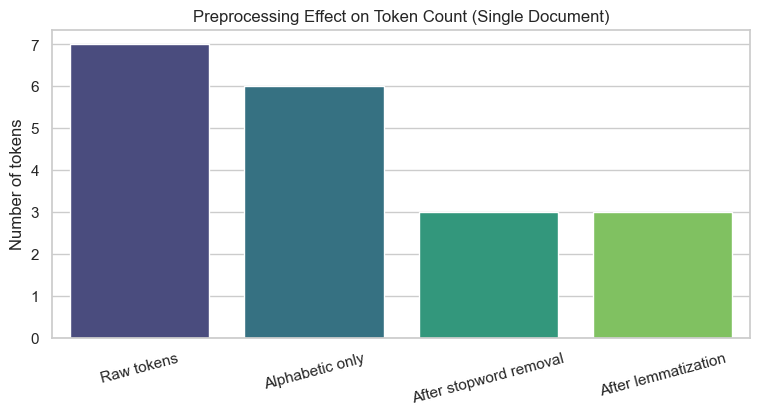

In [10]:
# Create a "before vs after" token count visualization.
stages = {
    'Raw tokens': len(raw_tokens),
    'Alphabetic only': len(alpha_tokens),
    'After stopword removal': len(no_stop_tokens),
    'After lemmatization': len(lemmatized_tokens)
}

plt.figure(figsize=(9, 4))
sns.barplot(x=list(stages.keys()), y=list(stages.values()), palette='viridis')
plt.title('Preprocessing Effect on Token Count (Single Document)')
plt.ylabel('Number of tokens')
plt.xticks(rotation=15)
plt.show()

### Step Review (Before/After Token Count Visualization)
**1) Brand-new student view:** Bars shrink because cleaning removes punctuation, stopwords, and short/noisy tokens. This shows preprocessing is changing what the model can see.

**2) ML professor view:** Strong visual; add the warning that over-cleaning can remove sentiment or negation cues. Encourage students to inspect examples, not just aggregate counts.

**3) Student re-check after professor edits:** The chart is clearer now: fewer tokens is not always “better”; it is a tradeoff between noise reduction and information loss.


In [12]:
# Apply preprocessing to the entire dataset.
df['clean_tokens'] = df['text'].apply(
    lambda x: preprocess_text(x, use_stemming=False, use_lemmatization=True)
)
df['clean_text'] = df['clean_tokens'].apply(lambda toks: ' '.join(toks))

# Show before/after examples for teaching clarity
for idx in [0, 5, 10]:
    print('=' * 100)
    print('BEFORE:', df.loc[idx, 'text'][:250].replace('\n', ' '))
    print('AFTER :', df.loc[idx, 'clean_text'][:250])
    print()

BEFORE: I thought that was Sandy Koufax.
AFTER : thought sandy koufax

BEFORE: While I don't mean to damn Henrik's attempt to be helpful here, he's using a common misconception that should be corrected.      Mach banding will occur for any image.  It is not the color quantization you see when you don't have enough bits.  It is 
AFTER : mean damn henrik attempt helpful using common misconception corrected mach banding occur image color quantization see enough bit human eye response transition edge intensity result color near transistion look brighter brighter side darker darker side

BEFORE: Now, that Clinton can get e-mail, i'm wondering if Congress is also going on line.. If so, does anyone have the address to reach them?? I'm also looking for Bill's e-mail address. please e-mail me, i am not a regualar reader of this newsgrouop.
AFTER : clinton get wondering congress also going line anyone address reach also looking bill address please regualar reader newsgrouop



C:\Users\Brent\AppData\Local\Temp\ipykernel_32028\2567002002.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_freq.values, y=word_freq.index, palette='mako')


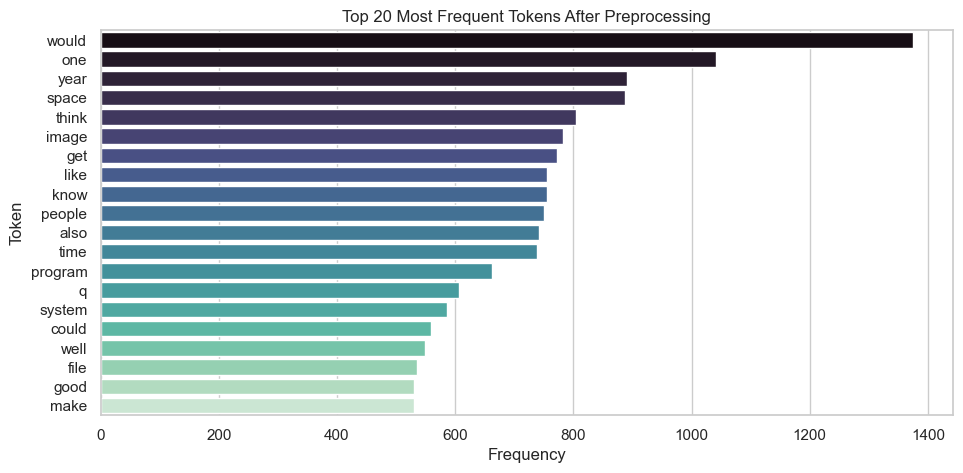

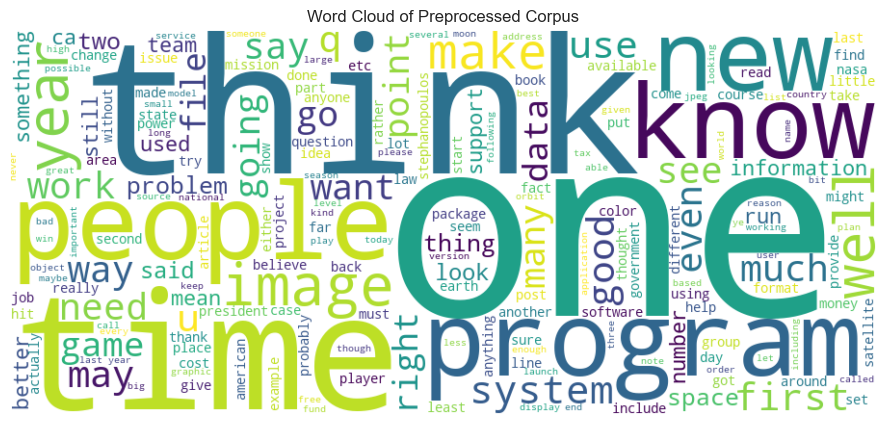

In [13]:
# Top words after preprocessing (across corpus)
all_tokens = [tok for doc in df['clean_tokens'] for tok in doc]
word_freq = pd.Series(all_tokens).value_counts().head(20)

plt.figure(figsize=(11, 5))
sns.barplot(x=word_freq.values, y=word_freq.index, palette='mako')
plt.title('Top 20 Most Frequent Tokens After Preprocessing')
plt.xlabel('Frequency')
plt.ylabel('Token')
plt.show()

# Word cloud can be intuitive for beginners (used as supportive visual, not rigorous analysis)
wc = WordCloud(width=900, height=400, background_color='white').generate(' '.join(all_tokens))
plt.figure(figsize=(12, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Preprocessed Corpus')
plt.show()

### Step Review (Top Tokens Visualization)
**1) Brand-new student view:** This chart shows the words that appear most after cleaning. It helps me inspect what vocabulary dominates the corpus.

**2) ML professor view:** Add a note about Zipf-like frequency behavior and that high frequency does not imply predictive utility. Suggest class-conditional token plots as a next step.

**3) Student re-check after professor edits:** I can now separate “common words” from “useful words for classification.”


---
# Section 3: Basic NLP Pipeline

A practical NLP pipeline usually follows this sequence:

**Raw text → Preprocessing → Feature extraction → Modeling → Prediction / Interpretation**

The next figure gives a conceptual map before we dive into feature representations.

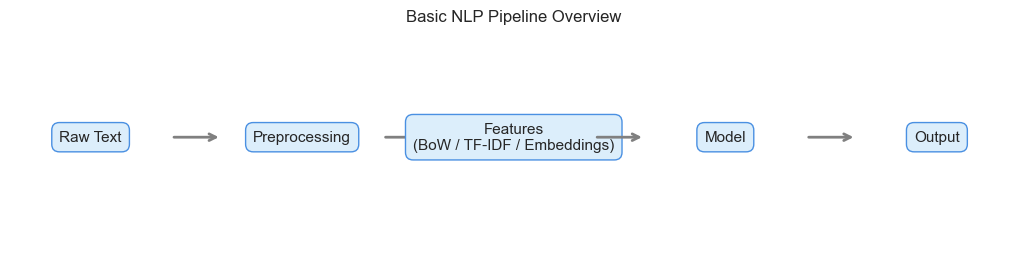

In [15]:
# A simple pipeline diagram using matplotlib annotations.
fig, ax = plt.subplots(figsize=(13, 2.8))
ax.axis('off')

steps = [
    'Raw Text',
    'Preprocessing',
    'Features\n(BoW / TF-IDF / Embeddings)',
    'Model',
    'Output'
]

x_positions = np.linspace(0.08, 0.92, len(steps))

for i, (x, step) in enumerate(zip(x_positions, steps)):
    ax.text(
        x, 0.5, step,
        ha='center',
        va='center',
        fontsize=11,
        bbox=dict(boxstyle='round,pad=0.5', fc='#dceefb', ec='#4a90e2')
    )
    if i < len(steps) - 1:
        ax.annotate(
            '',
            xy=(x_positions[i + 1] - 0.08, 0.5),
            xytext=(x + 0.08, 0.5),
            arrowprops=dict(arrowstyle='->', lw=2, color='gray')
        )

plt.title('Basic NLP Pipeline Overview')
plt.show()

### Step Review (Pipeline Diagram)
**1) Brand-new student view:** The diagram is a map of the whole workflow from raw text to model output. It helps me see order and dependency between steps.

**2) ML professor view:** Good sequence scaffold. Add callouts for where information can leak (e.g., vectorizer fit before split) and where hyperparameters enter.

**3) Student re-check after professor edits:** The pipeline now feels like a checklist with guardrails, not just a picture.


---
# Section 4: Bag of Words (BoW)

## Concept
Bag of Words represents each document as counts of vocabulary terms.

- It ignores word order.
- It keeps **how often** each word appears.
- Result: a large, sparse matrix.

This is often the first successful baseline in text classification.

In [16]:
# Use a cap on vocabulary size to keep classroom matrices manageable.
count_vectorizer = CountVectorizer(max_features=2000)
X_bow = count_vectorizer.fit_transform(df['clean_text'])

print('BoW matrix shape:', X_bow.shape)
print('Non-zero entries:', X_bow.nnz)
print('Sparsity (% non-zero):', round(100 * X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1]), 3), '%')

BoW matrix shape: (2159, 2000)
Non-zero entries: 88089
Sparsity (% non-zero): 2.04 %


In [17]:
# Inspect a tiny slice of the sparse matrix as a dense table for readability.
feature_names = count_vectorizer.get_feature_names_out()
small_matrix = pd.DataFrame(
    X_bow[:8, :12].toarray(),
    columns=feature_names[:12]
)
small_matrix

,aaa,ab,ability,able,abort,abortion,absolutely,abstract,abuse,academic,acceleration,accept
0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0


C:\Users\Brent\AppData\Local\Temp\ipykernel_32028\2082086397.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_words_bow, x='count', y='word', palette='crest')


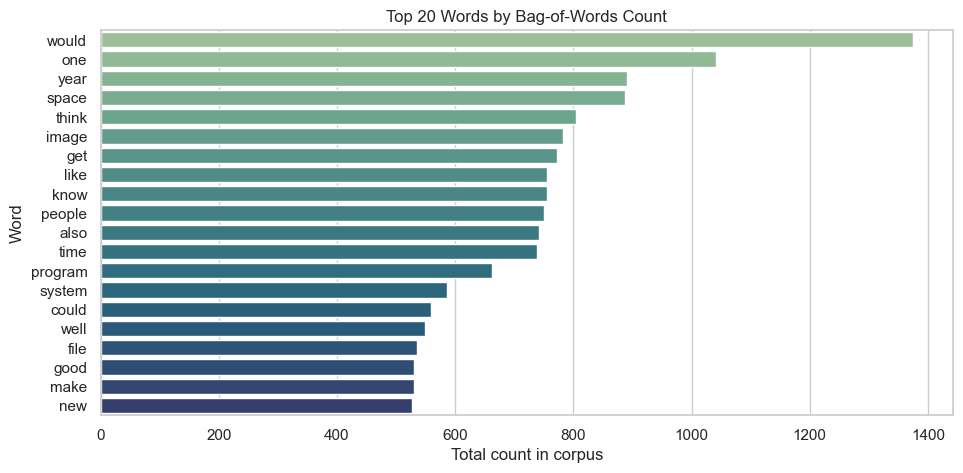

In [18]:
# Top BoW features by total count across the corpus.
bow_sum = np.asarray(X_bow.sum(axis=0)).flatten()
idx = np.argsort(bow_sum)[-20:][::-1]

top_words_bow = pd.DataFrame({
    'word': feature_names[idx],
    'count': bow_sum[idx]
})

plt.figure(figsize=(11, 5))
sns.barplot(data=top_words_bow, x='count', y='word', palette='crest')
plt.title('Top 20 Words by Bag-of-Words Count')
plt.xlabel('Total count in corpus')
plt.ylabel('Word')
plt.show()

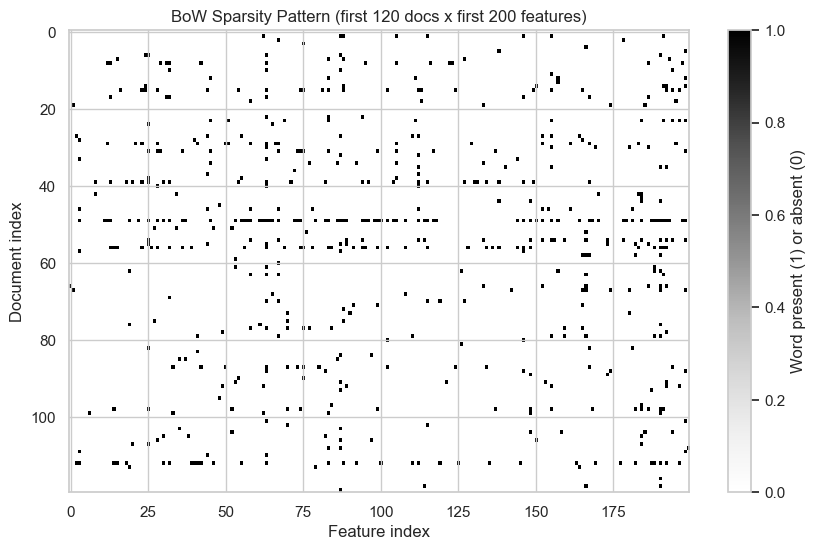

In [19]:
# Sparse matrix visualization (presence/absence in a sample)
# We plot a binary view for the first 120 docs x first 200 features.
sample_sparse = (X_bow[:120, :200].toarray() > 0).astype(int)

plt.figure(figsize=(10, 6))
plt.imshow(sample_sparse, aspect='auto', cmap='Greys', interpolation='nearest')
plt.title('BoW Sparsity Pattern (first 120 docs x first 200 features)')
plt.xlabel('Feature index')
plt.ylabel('Document index')
plt.colorbar(label='Word present (1) or absent (0)')
plt.show()

### Step Review (Sparse BoW Matrix Visualization)
**1) Brand-new student view:** Dots/colored cells mean a word appears in a document. Most empty cells show text matrices are sparse.

**2) ML professor view:** Emphasize computational implications: sparse linear models scale well; dense conversion is for teaching only. Also mention orderless representation limits semantics.

**3) Student re-check after professor edits:** I now understand both *what* sparsity looks like and *why* BoW misses word order/context.


---
# Section 5: TF-IDF

## Why not only term frequency?
Words that appear in almost every document are less informative for classification.

**TF-IDF (Term Frequency × Inverse Document Frequency)** gives higher weight to words that are:
- frequent in a specific document,
- but not frequent across all documents.

Let's build TF-IDF features and compare them with BoW.

In [20]:
tfidf_vectorizer = TfidfVectorizer(max_features=2000)
X_tfidf = tfidf_vectorizer.fit_transform(df['clean_text'])

print('TF-IDF matrix shape:', X_tfidf.shape)
print('Non-zero entries:', X_tfidf.nnz)

TF-IDF matrix shape: (2159, 2000)
Non-zero entries: 88089


C:\Users\Brent\AppData\Local\Temp\ipykernel_32028\785231125.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_words_bow.head(12), x='count', y='word', ax=axes[0], palette='Blues_r')
C:\Users\Brent\AppData\Local\Temp\ipykernel_32028\785231125.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_words_tfidf.head(12), x='tfidf_score_sum', y='word', ax=axes[1], palette='Oranges_r')


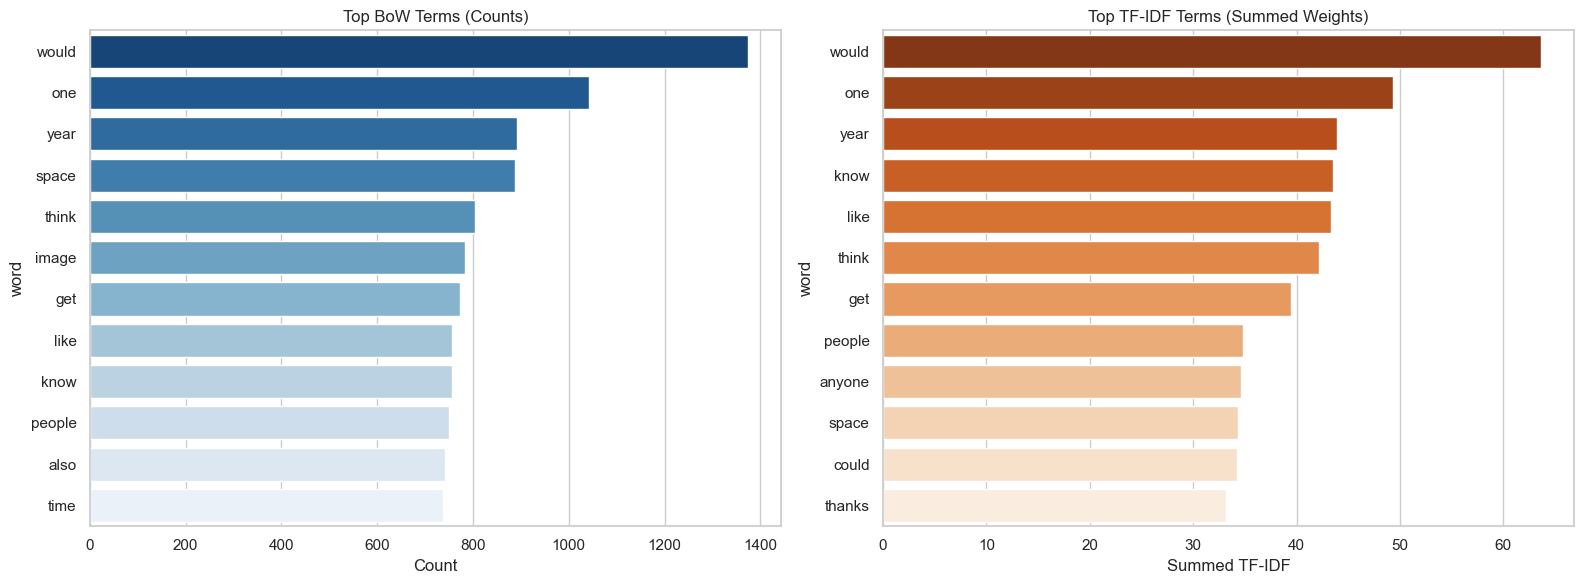

In [21]:
# Compare top features: BoW count vs TF-IDF global score.
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_sum = np.asarray(X_tfidf.sum(axis=0)).flatten()
idx_tfidf = np.argsort(tfidf_sum)[-20:][::-1]

top_words_tfidf = pd.DataFrame({
    'word': tfidf_feature_names[idx_tfidf],
    'tfidf_score_sum': tfidf_sum[idx_tfidf]
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top_words_bow.head(12), x='count', y='word', ax=axes[0], palette='Blues_r')
axes[0].set_title('Top BoW Terms (Counts)')
axes[0].set_xlabel('Count')

sns.barplot(data=top_words_tfidf.head(12), x='tfidf_score_sum', y='word', ax=axes[1], palette='Oranges_r')
axes[1].set_title('Top TF-IDF Terms (Summed Weights)')
axes[1].set_xlabel('Summed TF-IDF')

plt.tight_layout()
plt.show()

### Step Review (BoW vs TF-IDF Comparison)
**1) Brand-new student view:** We compare two ways of scoring words: raw counts vs importance weighted by rarity across documents.

**2) ML professor view:** Clarify that TF-IDF is unsupervised weighting and can still overvalue rare but irrelevant terms. Mention normalization choices affect geometry.

**3) Student re-check after professor edits:** I now read this as “frequency adjusted by uniqueness,” not “smart counts that are always better.”


---
# Section 6: Simple Classification Walkthrough

Now we use TF-IDF + Multinomial Naive Bayes for a complete, fast classroom classifier.

Why this model?
- Very fast to train
- Works well as a baseline for text
- Easy to explain for first-time learners

In [23]:
# Split data for honest evaluation.
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'],
    df['label'],
    test_size=0.25,
    random_state=42,
    stratify=df['label']
)

# Build end-to-end pipeline: vectorization + model.
clf = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=3000)),
    ('nb', MultinomialNB())
])

# Train and predict
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.3f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.893

Classification Report:
                    precision    recall  f1-score   support

     comp.graphics       0.84      0.94      0.88       142
rec.sport.baseball       0.88      0.93      0.90       141
         sci.space       0.91      0.84      0.87       144
talk.politics.misc       0.98      0.86      0.92       113

          accuracy                           0.89       540
         macro avg       0.90      0.89      0.89       540
      weighted avg       0.90      0.89      0.89       540



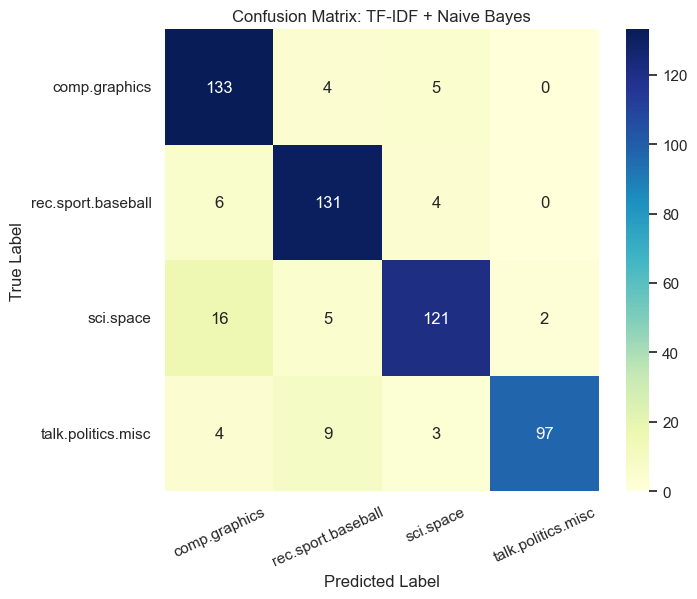

In [24]:
# Confusion matrix visual
labels_sorted = sorted(df['label'].unique())
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.title('Confusion Matrix: TF-IDF + Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=25)
plt.yticks(rotation=0)
plt.show()

### Step Review (Confusion Matrix Visualization)
**1) Brand-new student view:** Diagonal cells are correct predictions; off-diagonal cells are mistakes. This tells me *which* classes are confused.

**2) ML professor view:** Add per-class recall/precision linkage and caution against interpreting counts without class support. Consider normalized confusion matrix for readability.

**3) Student re-check after professor edits:** This is more useful than one accuracy number because I can see the pattern of errors.


In [25]:
# Inspect a few predictions to connect metrics back to actual text.
results_df = pd.DataFrame({'text': X_test.values, 'true': y_test.values, 'pred': y_pred})
results_df['correct'] = results_df['true'] == results_df['pred']

print('Sample predictions:')
for i, row in results_df.sample(6, random_state=7).iterrows():
    print('='*100)
    print(f"TRUE: {row['true']} | PRED: {row['pred']} | CORRECT: {row['correct']}")
    print('TEXT SNIPPET:', row['text'][:240])

Sample predictions:
TRUE: talk.politics.misc | PRED: talk.politics.misc | CORRECT: True
TEXT SNIPPET: etc etc sure woman hypothesis trust report people idea median bullshit article reported men sex time week elf many time fill one questionnaire statistic took consideration different class background marital status etc information sampling g
TRUE: comp.graphics | PRED: comp.graphics | CORRECT: True
TEXT SNIPPET: file format autodesk animation studio available thanks gary
TRUE: rec.sport.baseball | PRED: rec.sport.baseball | CORRECT: True
TEXT SNIPPET: alomar fan left rbi fan run list dependant team large extent frank thomas hit first lose lot rbi anyways many place hitter known drive run happen often unlikely devon white obp front
TRUE: sci.space | PRED: sci.space | CORRECT: True
TEXT SNIPPET: dillon comment space food stick may bad digestive property think think nasa food product designed low fiber product minimize difficulty waste disposal doubt deploy anything caused whole sale gi di

### Step Review (Prediction Examples Table)
**1) Brand-new student view:** Real examples connect model metrics to actual language mistakes. I can inspect why predictions failed.

**2) ML professor view:** Encourage structured error taxonomy (domain terms, ambiguity, preprocessing artifacts, label noise). This builds model-debugging habits early.

**3) Student re-check after professor edits:** I now know what to look for during error analysis, not just whether the prediction is right/wrong.


---
# Section 7: What Embeddings Are

BoW/TF-IDF are sparse and mostly frequency-based. Embeddings are different:

- Each word/sentence is mapped to a **dense vector** (e.g., 384 numbers).
- Semantic relationships can be reflected as geometric closeness.
- Similar meanings often get similar vectors.

We now switch to **IMDB reviews** for semantic interpretation.

In [26]:
# Load IMDB dataset (train split) and keep a small subset for fast class demos.
imdb = load_dataset('imdb')
imdb_train = imdb['train'].shuffle(seed=42).select(range(1200))

imdb_df = pd.DataFrame({
    'text': imdb_train['text'],
    'label_num': imdb_train['label']
})
imdb_df['label'] = imdb_df['label_num'].map({0: 'negative', 1: 'positive'})

print('IMDB subset size:', len(imdb_df))
imdb_df[['text', 'label']].head(3)

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

IMDB subset size: 1200


,text,label
0,There is no relation at all between Fortier an...,positive
1,This movie is a great. The plot is very true t...,positive
2,"George P. Cosmatos' ""Rambo: First Blood Part I...",negative


C:\Users\Brent\AppData\Local\Temp\ipykernel_32028\2814536100.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=imdb_df, x='label', palette='Set1', ax=axes[0])


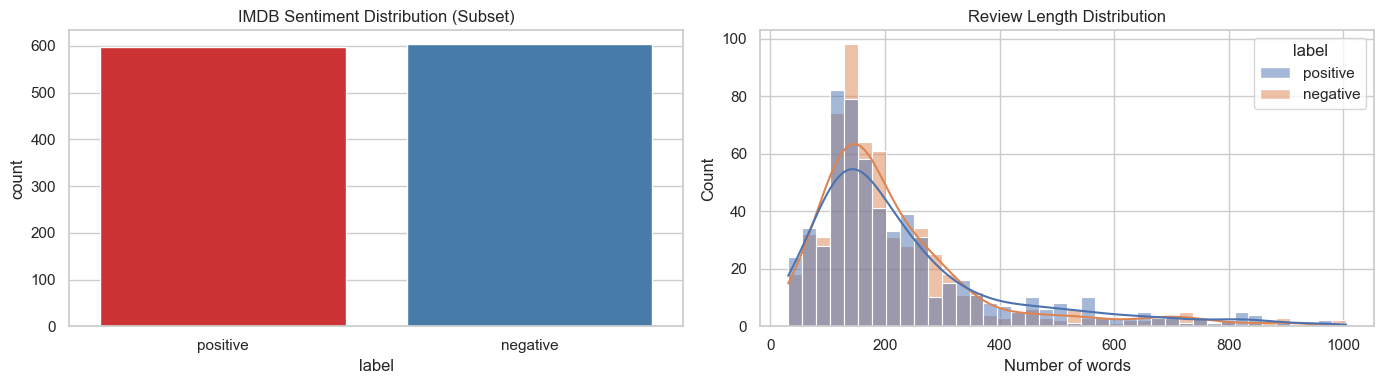

In [27]:
# Basic sentiment distribution and length visuals.
imdb_df['length_words'] = imdb_df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(data=imdb_df, x='label', palette='Set1', ax=axes[0])
axes[0].set_title('IMDB Sentiment Distribution (Subset)')

sns.histplot(data=imdb_df, x='length_words', hue='label', bins=40, kde=True, ax=axes[1])
axes[1].set_title('Review Length Distribution')
axes[1].set_xlabel('Number of words')

plt.tight_layout()
plt.show()

### Step Review (IMDB Distribution and Length Visuals)
**1) Brand-new student view:** Sentiment balance and review length tell me whether data is fair and how long texts usually are.

**2) ML professor view:** Add that sequence length affects truncation, memory, and model choice. Recommend percentiles (p50/p90/p99) rather than only mean intuition.

**3) Student re-check after professor edits:** I can connect dataset shape to practical modeling decisions like max token length.


---
# Section 8: Static(ish) Sentence Embeddings and Semantic Similarity

To keep the demo lightweight, we use a pretrained **SentenceTransformer** model.

This gives us fixed-length vectors for whole texts. We can then:
- compute cosine similarity,
- visualize semantic neighborhoods,
- show clustering tendencies in 2D.

In [28]:
# Load a compact sentence embedding model suitable for classroom runtime.
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')

# Use a small sample for quick embedding + plotting.
sample_n = 220
sample_reviews = imdb_df['text'].iloc[:sample_n].tolist()
sample_labels = imdb_df['label'].iloc[:sample_n].tolist()

# Encode reviews into dense vectors.
review_embeddings = sentence_model.encode(sample_reviews, show_progress_bar=False)
print('Embedding matrix shape:', review_embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding matrix shape: (220, 384)


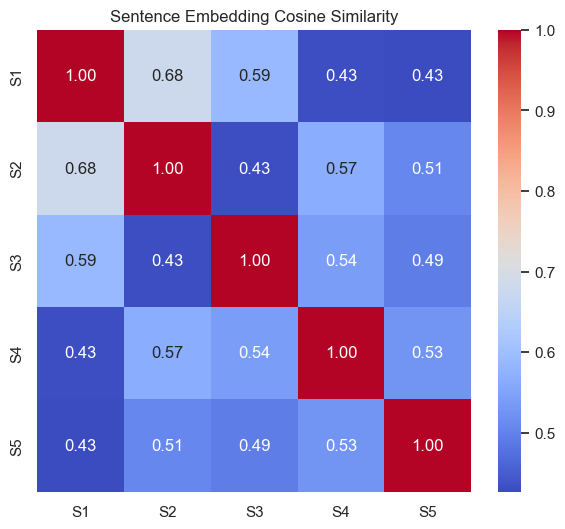

S1: This movie was fantastic and emotionally moving.
S2: An excellent film with great acting and story.
S3: This movie was boring and painfully slow.
S4: A terrible film with weak plot and poor dialogue.
S5: The soundtrack was decent but the story was average.


In [29]:
# Cosine similarity heatmap for selected short example sentences.
example_sentences = [
    'This movie was fantastic and emotionally moving.',
    'An excellent film with great acting and story.',
    'This movie was boring and painfully slow.',
    'A terrible film with weak plot and poor dialogue.',
    'The soundtrack was decent but the story was average.'
]

ex_emb = sentence_model.encode(example_sentences)
# Normalize then compute cosine similarity via matrix multiply
ex_norm = ex_emb / np.linalg.norm(ex_emb, axis=1, keepdims=True)
sim_matrix = ex_norm @ ex_norm.T

plt.figure(figsize=(7, 6))
sns.heatmap(sim_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=[f'S{i+1}' for i in range(len(example_sentences))],
            yticklabels=[f'S{i+1}' for i in range(len(example_sentences))])
plt.title('Sentence Embedding Cosine Similarity')
plt.show()

for i, s in enumerate(example_sentences, 1):
    print(f'S{i}: {s}')

### Step Review (Sentence Similarity Heatmap)
**1) Brand-new student view:** Darker/brighter cells indicate how close two sentence meanings are in embedding space.

**2) ML professor view:** Mention cosine similarity bounds and anisotropy caveats in embedding spaces. Similarity is useful, but task calibration still matters.

**3) Student re-check after professor edits:** I now interpret colors as relative semantic closeness, not absolute truth.


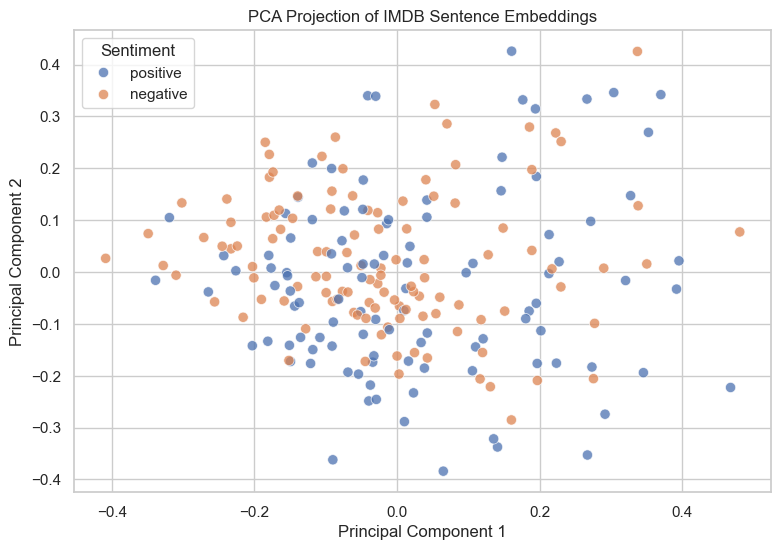

In [30]:
# 2D projection of review embeddings with PCA.
pca = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(review_embeddings)

plot_df = pd.DataFrame({
    'pc1': emb_2d[:, 0],
    'pc2': emb_2d[:, 1],
    'label': sample_labels
})

plt.figure(figsize=(9, 6))
sns.scatterplot(data=plot_df, x='pc1', y='pc2', hue='label', alpha=0.75, s=55)
plt.title('PCA Projection of IMDB Sentence Embeddings')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Sentiment')
plt.show()

### Step Review (2D Embedding Projection)
**1) Brand-new student view:** Dots that cluster together represent reviews with similar embedding patterns; colors show sentiment labels.

**2) ML professor view:** Add dimensionality-reduction caution: PCA preserves variance, not class separability. 2D plots are intuition tools, not proof of linear separability.

**3) Student re-check after professor edits:** I understand this picture is a helpful summary view, not the actual full embedding geometry.


---
# Section 9: Contextual Embeddings (Same Word, Different Meaning)

Now we show a major idea behind modern LLM-style language understanding:

> The vector for a word depends on **context**.

We will use ambiguous words (`bank`, `bat`, `light`, `charge`, `cold`) with sentence pairs.
Then we extract token vectors from a pretrained BERT model and compare cosine similarity.

In [31]:
# Ambiguous-word mini dataset (custom classroom examples)
ambiguous_examples = [
    ('bank', 'I deposited cash at the bank.', 'We sat by the river bank.'),
    ('bat', 'The bat flew out of the cave.', 'He swung the bat at the ball.'),
    ('light', 'This laptop is light.', 'Please turn on the light.'),
    ('charge', 'The battery holds charge for ten hours.', 'The lawyer filed a criminal charge.'),
    ('cold', 'I caught a cold last week.', 'The cold wind made my face numb.')
]

ambiguous_examples

[('bank', 'I deposited cash at the bank.', 'We sat by the river bank.'),
 ('bat', 'The bat flew out of the cave.', 'He swung the bat at the ball.'),
 ('light', 'This laptop is light.', 'Please turn on the light.'),
 ('charge',
  'The battery holds charge for ten hours.',
  'The lawyer filed a criminal charge.'),
 ('cold', 'I caught a cold last week.', 'The cold wind made my face numb.')]

In [33]:
# Load a compact BERT model for contextual token embeddings.
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
bert_model = AutoModel.from_pretrained('distilbert-base-uncased')
bert_model.eval()

print('Contextual model loaded.')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Contextual model loaded.


In [34]:
def get_target_token_embedding(sentence, target_word):
    """
    Extract one contextual embedding for the first token piece matching target_word.

    Important teaching point:
    - BERT uses subword tokenization.
    - We find the index where the target appears (or starts with target piece).
    """
    encoded = tokenizer(sentence, return_tensors='pt')
    tokens = tokenizer.convert_ids_to_tokens(encoded['input_ids'][0])

    with torch.no_grad():
        output = bert_model(**encoded)

    hidden = output.last_hidden_state[0]  # [seq_len, hidden_dim]

    # Search token list for exact target or continuation pattern.
    # This is a simplified educational approach (good enough for demo words here).
    target_idx = None
    for i, tok in enumerate(tokens):
        if tok == target_word or tok == f'##{target_word}' or tok.startswith(target_word):
            target_idx = i
            break

    if target_idx is None:
        return None, tokens

    vec = hidden[target_idx]
    return vec, tokens

# Compute similarity between contextual vectors for same word in different sentences.
rows = []
for word, sent1, sent2 in ambiguous_examples:
    v1, t1 = get_target_token_embedding(sent1.lower(), word)
    v2, t2 = get_target_token_embedding(sent2.lower(), word)

    if v1 is not None and v2 is not None:
        sim = F.cosine_similarity(v1.unsqueeze(0), v2.unsqueeze(0)).item()
    else:
        sim = np.nan

    rows.append({'word': word, 'sentence_a': sent1, 'sentence_b': sent2, 'cosine_similarity': sim})

context_df = pd.DataFrame(rows)
context_df

,word,sentence_a,sentence_b,cosine_similarity
0,bank,I deposited cash at the bank.,We sat by the river bank.,0.725805
1,bat,The bat flew out of the cave.,He swung the bat at the ball.,0.709193
2,light,This laptop is light.,Please turn on the light.,0.680374
3,charge,The battery holds charge for ten hours.,The lawyer filed a criminal charge.,0.558493
4,cold,I caught a cold last week.,The cold wind made my face numb.,0.783766


C:\Users\Brent\AppData\Local\Temp\ipykernel_32028\2431543293.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=context_df, x='word', y='cosine_similarity', palette='rocket')


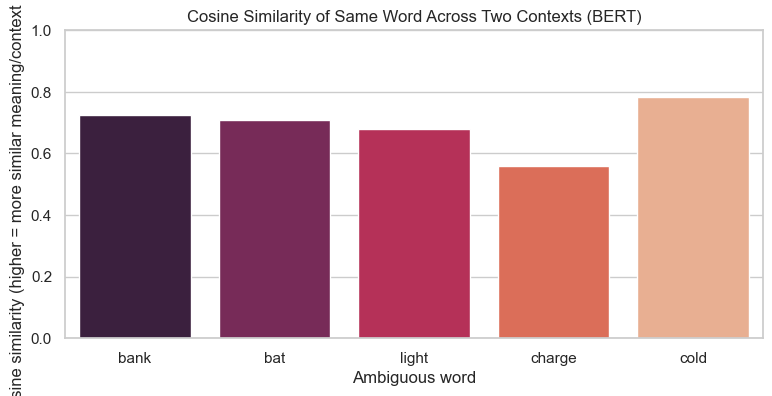

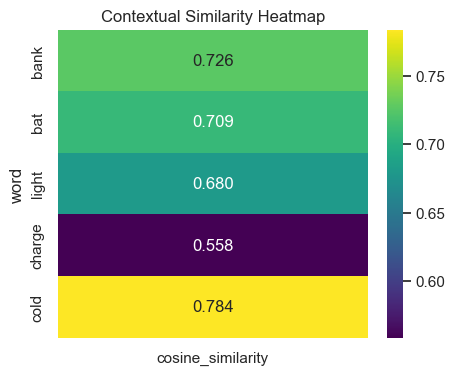

In [35]:
# Visualize how similarity changes across ambiguous words.
plt.figure(figsize=(9, 4))
sns.barplot(data=context_df, x='word', y='cosine_similarity', palette='rocket')
plt.ylim(0, 1)
plt.title('Cosine Similarity of Same Word Across Two Contexts (BERT)')
plt.ylabel('Cosine similarity (higher = more similar meaning/context usage)')
plt.xlabel('Ambiguous word')
plt.show()

# Heatmap version for teaching emphasis
heat = context_df[['word', 'cosine_similarity']].set_index('word')
plt.figure(figsize=(5, 4))
sns.heatmap(heat, annot=True, fmt='.3f', cmap='viridis', cbar=True)
plt.title('Contextual Similarity Heatmap')
plt.show()

### Step Review (Contextual Similarity by Word Sense)
**1) Brand-new student view:** The same word can have different meanings; contextual models produce different vectors based on nearby words.

**2) ML professor view:** Great example. Add tokenization caveat (subword splits) and note that layer choice changes semantic/syntactic emphasis.

**3) Student re-check after professor edits:** I now see why context-aware embeddings outperform static word representations for ambiguous language.


**Interpretation:**
- If the same word is used with different meanings, vector similarity often drops.
- This is exactly what contextual models capture better than static vectors.
- In static embeddings, one word usually has one fixed vector regardless of sentence context.

---
# Section 10: Complete NLP Walkthrough Recap

Let's summarize what we built end-to-end:

1. Loaded raw text (20 Newsgroups).
2. Explored class balance and document lengths.
3. Applied preprocessing.
4. Created BoW and TF-IDF features.
5. Trained and evaluated a baseline classifier.
6. Switched to IMDB for semantic embedding demonstrations.
7. Visualized sentence-level semantic structure.
8. Demonstrated contextual token meaning changes with BERT.

In [36]:
# Final comparison table for students.
comparison = pd.DataFrame([
    {
        'Representation': 'Bag of Words',
        'Type': 'Sparse counts',
        'Captures word order?': 'No',
        'Meaning-aware?': 'Very limited',
        'Best use': 'Simple baselines, topic clues'
    },
    {
        'Representation': 'TF-IDF',
        'Type': 'Sparse weighted counts',
        'Captures word order?': 'No',
        'Meaning-aware?': 'Limited',
        'Best use': 'Stronger classical text classification'
    },
    {
        'Representation': 'Static Embeddings',
        'Type': 'Dense vectors',
        'Captures word order?': 'Indirectly (sentence encoders vary)',
        'Meaning-aware?': 'Yes, general semantics',
        'Best use': 'Similarity search, semantic retrieval'
    },
    {
        'Representation': 'Contextual Embeddings',
        'Type': 'Dense context-dependent vectors',
        'Captures word order?': 'Yes',
        'Meaning-aware?': 'Strongly',
        'Best use': 'Modern NLP, LLM foundations'
    }
])

comparison

,Representation,Type,Captures word order?,Meaning-aware?,Best use
0,Bag of Words,Sparse counts,No,Very limited,"Simple baselines, topic clues"
1,TF-IDF,Sparse weighted counts,No,Limited,Stronger classical text classification
2,Static Embeddings,Dense vectors,Indirectly (sentence encoders vary),"Yes, general semantics","Similarity search, semantic retrieval"
3,Contextual Embeddings,Dense context-dependent vectors,Yes,Strongly,"Modern NLP, LLM foundations"


### Step Review (Final Comparison Table)
**1) Brand-new student view:** This table summarizes what each method is good at and where it struggles. It is a quick study guide.

**2) ML professor view:** Include assumptions and failure modes per method (order invariance, OOV handling, compute cost). This improves transfer to real project design.

**3) Student re-check after professor edits:** The recap now helps me choose methods intentionally, not memorize buzzwords.


## Optional Bridge: From Classical NLP to Modern LLMs

A simple historical progression:

- **BoW**: "Which words appear?"
- **TF-IDF**: "Which words are important in this document?"
- **Embeddings**: "Which words/sentences are semantically similar?"
- **Contextual embeddings (BERT/Transformers)**: "What does this token mean *in this sentence*?"
- **LLMs**: Stack many transformer layers and train at large scale so the model can perform generation, reasoning-like behaviors, QA, summarization, coding, and more.

This notebook gives you the conceptual ladder needed to understand why modern LLMs are powerful and what they improved over classical methods.

# Suggested Exercises for Students

1. Add another 20 Newsgroups category and observe confusion matrix changes.
2. Compare Naive Bayes with Logistic Regression.
3. Turn stemming on/off and measure classification impact.
4. Add more ambiguous words to the contextual section and analyze similarities.
5. Try another SentenceTransformer model and compare embedding plots.